In [8]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


balanced = pd.read_csv("balanced_log.csv")
balanced

,center,left,right,steering,throttle,brake,speed
0,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.05,1.0,0,30.19068
1,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19069
2,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.00,1.0,0,30.19027
3,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18975
4,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,-0.10,1.0,0,30.18807
...,...,...,...,...,...,...,...
2607,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.85,1.0,0,30.10747
2608,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.15,1.0,0,30.18419
2609,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.05,1.0,0,30.18972
2610,D:\DPS 920\DPS920_final_project\IMG\center_202...,D:\DPS 920\DPS920_final_project\IMG\left_2026_...,D:\DPS 920\DPS920_final_project\IMG\right_2026...,0.10,1.0,0,30.18936


# Data Augmentation

- slight right bias
- removed overabundance of "straight" frames and rows
- only included rows where the throttle was fully pressed
- **Data collection was done using keyboard keys (may need to retry with mouse steering)**


## Data Split

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    balanced, test_size=0.2, random_state=42
)

# Data Augmentation

- slight right bias
- removed overabundance of "straight" frames and rows
- only included rows where the throttle was fully pressed
- **Data collection was done using keyboard keys (may need to retry with mouse steering)**


## Apply Augmentations

In [10]:
from augmentations import (
    augment_flip, augment_brightness, augment_zoom,
    augment_pan, augment_rotate
)

def random_augment(img, steering):
    # np.random.rand generates a new number each if statement
    if np.random.rand() < 0.5:
        print("flipped")
        img, steering = augment_flip(img, steering)
    if np.random.rand() < 0.5:
        print("brightness adjusted")   
        img = augment_brightness(img)
    if np.random.rand() < 0.5:
        print("zoomed in")
        img = augment_zoom(img)
    if np.random.rand() < 0.5:
        print("panned")
        img = augment_pan(img)
    if np.random.rand() < 0.5:
        print("rotated")
        img = augment_rotate(img)
    return img, steering

['center', 'left', 'right', 'steering', 'throttle', 'brake', 'speed']
D:\DPS 920\DPS920_final_project\IMG\center_2026_07_28_11_07_40_113.jpg
flipped
rotated


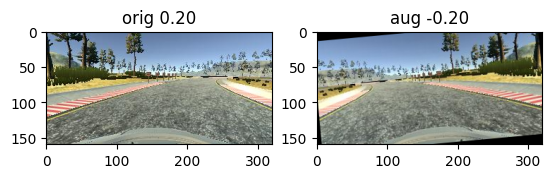

In [11]:
import cv2
import matplotlib.pyplot as plt

print(train_df.columns.tolist())  # must include 'center'

row = train_df.iloc[0]
path = row["center"]              # quotes required
print(path)

img_bgr = cv2.imread(path)
if img_bgr is None:
    raise FileNotFoundError(path)

img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img2, steer2 = random_augment(img, float(row["steering"]))

plt.subplot(1, 2, 1); plt.imshow(img); plt.title(f"orig {row['steering']:.2f}")
plt.subplot(1, 2, 2); plt.imshow(img2); plt.title(f"aug {steer2:.2f}")
plt.show()